# Tarea 2 — Detección de Contribuciones Científicas en Español
## Proyecto FLAG · Grupo 2 · MAIA 2026

**Objetivo:** Clasificar fragmentos de texto científico en español de forma binaria:
- `ES_CONTRIBUCION` (1): el fragmento describe un aporte científico original
- `NO_ES_CONTRIBUCION` (0): el fragmento no lo hace

**Input del modelo:** únicamente el texto del fragmento.  
No se usan `relative_pos`, `contr_type` ni ningún metadato — el modelo aprende semántica pura.

| Actividad | Descripción |
|-----------|------------|
| **A5** | Fine-tuning de SciBETO-large (encoder español científico) |
| **A6** | LLMs open-weight: Llama 3.1 8B, zero-shot y few-shot |
| **A7** | LLM comercial vía API (GPT-4o) |
| **A10** | Análisis comparativo cuantitativo y cualitativo |

**Datos:**
- `train.jsonl` / `val.jsonl` — campo `text` + `a1_class`
- `anotacion_referencia.csv` — campo `snippet` + `auto_label` (nunca usado en entrenamiento)

**W&B:** proyecto `maia-flag-document-analysis` · group `task2`

---
## 0. Instalación de dependencias

In [1]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install(
    "transformers>=4.40",
    "datasets",
    "accelerate>=0.27",
    "bitsandbytes",
    "scikit-learn",
    "pandas",
    "matplotlib",
    "seaborn",
    "wandb",
    "tqdm",
    "openai",
)
print(" Dependencias instaladas")

✓ Dependencias instaladas


---
## 1. Configuración global y W&B

`group="task2"` en todos los `wandb.init()` mantiene estos runs separados
de los experimentos de Tarea 1 en el dashboard, sin solapamiento en gráficas.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
os.environ["WANDB_API_KEY"] = "11"  # reemplazar con tu key

In [4]:
import os, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import torch
from pathlib import Path
from tqdm import tqdm
from google.colab import userdata

# Credenciales opcionales
try:
    OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
    HF_TOKEN       = userdata.get("HF_TOKEN")
except Exception:
    OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
    HF_TOKEN       = os.environ.get("HF_TOKEN", "")

wandb.login()

# W&B — estas env-vars hacen que HuggingFace Trainer reporte aquí
# en vez de crear un proyecto llamado "huggingface" por defecto
os.environ["WANDB_PROJECT"] = "maia-flag-document-analysis"
os.environ["WANDB_ENTITY"]  = "natamoncada10-universidad-de-los-andes"

WB_PROJECT = "maia-flag-document-analysis"
WB_ENTITY  = "natamoncada10-universidad-de-los-andes"
WB_GROUP   = "task2"  # ← diferencia de task1 en el dashboard

# Rutas — ajustar si tu estructura de Drive es distinta
DRIVE_ROOT = "/content/drive/MyDrive/maia_datasets"
TRAIN_PATH = f"{DRIVE_ROOT}/train.jsonl"
VAL_PATH   = f"{DRIVE_ROOT}/val.jsonl"
TEST_PATH  = f"{DRIVE_ROOT}/anotacion_referencia.csv"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")

print(f"✓ Configuración lista")
print(f"  W&B project : {WB_PROJECT}")
print(f"  W&B group   : {WB_GROUP}")
print(f"  Device      : {'CUDA ✓' if torch.cuda.is_available() else 'CPU ⚠️'}")
if torch.cuda.is_available():
    print(f"  GPU         : {torch.cuda.get_device_name(0)}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: juanperez4364985 (natamoncada10-universidad-de-los-andes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ Configuración lista
  W&B project : maia-flag-document-analysis
  W&B group   : task2
  Device      : CUDA ✓
  GPU         : NVIDIA A100-SXM4-40GB


---
## 2. Carga de datos

In [5]:
# ── Cargadores ────────────────────────────────────────────────────────────────

def load_jsonl(path: str) -> pd.DataFrame:
    """Carga un JSONL en DataFrame. El campo de texto es 'text'."""
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)


def load_test_csv(path: str) -> pd.DataFrame:
    """
    Carga anotacion_referencia.csv y lo alinea al esquema del pipeline.

    Columnas originales del CSV:
      snippet    → text      (el texto del fragmento)
      auto_label → a1_class  (etiqueta numérica: 1 o 0)
      a1_class_auto → a1_label (etiqueta en texto: ES_CONTRIBUCION / NO_ES_CONTRIBUCION)

    El resto de columnas (contr_type, relative_pos, etc.) NO se usan como
    features del modelo — solo sirven para el análisis exploratorio.
    """
    df = pd.read_csv(path, encoding="utf-8")

    # Renombrar columnas al esquema común
    df = df.rename(columns={
        "snippet"      : "text",
        "auto_label"   : "a1_class",
        "a1_class_auto": "a1_label",
    })

    # Garantizar que a1_class sea entero 0/1
    df["a1_class"] = pd.to_numeric(df["a1_class"], errors="coerce").fillna(0).astype(int)

    # Si a1_label no existe, derivarla
    if "a1_label" not in df.columns:
        df["a1_label"] = df["a1_class"].map({1: "ES_CONTRIBUCION", 0: "NO_ES_CONTRIBUCION"})

    # word_count: calcular desde el texto si no viene en el CSV
    if "word_count" not in df.columns or df["word_count"].isna().all():
        df["word_count"] = df["text"].str.split().str.len()
    else:
        df["word_count"] = pd.to_numeric(df["word_count"], errors="coerce").fillna(0).astype(int)

    return df


# ── Cargar las tres particiones ────────────────────────────────────────────────
df_train = load_jsonl(TRAIN_PATH)
df_val   = load_jsonl(VAL_PATH)
df_test  = load_test_csv(TEST_PATH)

# Normalizar a1_class en train/val por si acaso
for df in [df_train, df_val]:
    if "a1_class" not in df.columns:
        df["a1_class"] = (df["a1_label"] == "ES_CONTRIBUCION").astype(int)

# Calcular word_count en train/val si no viene
for df in [df_train, df_val]:
    if "word_count" not in df.columns:
        df["word_count"] = df["text"].str.split().str.len()

# Resumen
print("Particiones cargadas:")
for df, name in [(df_train,"train"), (df_val,"val"), (df_test,"test (referencia)")]:
    pos = df["a1_class"].sum()
    neg = (df["a1_class"] == 0).sum()
    print(f"  {name:22s}: {len(df):5,} fragmentos | ES_CONTR={pos:,} | NO_CONTR={neg:,}")

print(f"\nTotal train+val: {len(df_train)+len(df_val):,}")
print(f"Test (anotacion_referencia.csv — NUNCA usado en entrenamiento): {len(df_test)}")

Particiones cargadas:
  train                 : 1,600 fragmentos | ES_CONTR=794 | NO_CONTR=806
  val                   :   400 fragmentos | ES_CONTR=206 | NO_CONTR=194
  test (referencia)     :   200 fragmentos | ES_CONTR=100 | NO_CONTR=100

Total train+val: 2,000
Test (anotacion_referencia.csv — NUNCA usado en entrenamiento): 200


---
## 3. Análisis exploratorio (EDA)

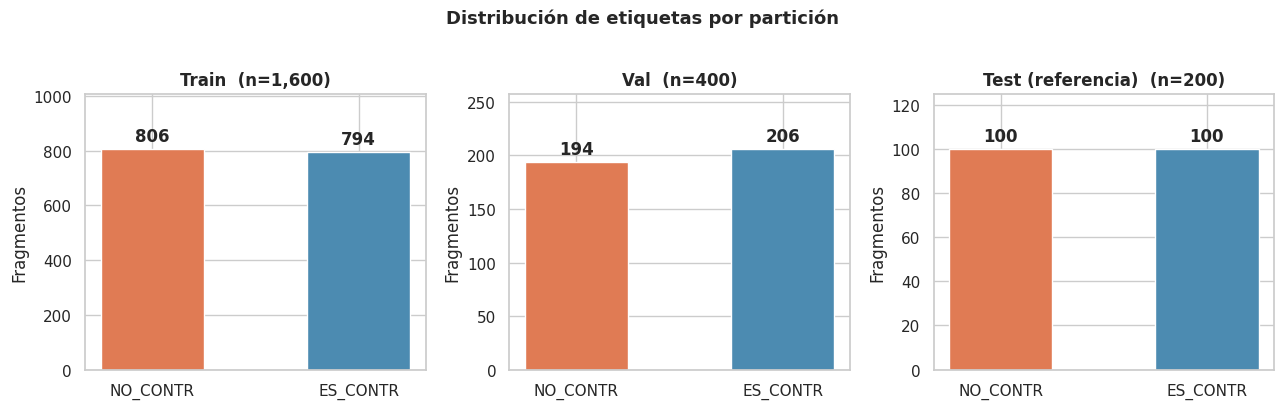

Distribución train: {0: np.int64(806), 1: np.int64(794)}
Distribución val  : {0: np.int64(194), 1: np.int64(206)}
Distribución test : {0: np.int64(100), 1: np.int64(100)}


In [6]:
# ── Distribución de etiquetas ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (df, name) in zip(axes, [
    (df_train, "Train"), (df_val, "Val"), (df_test, "Test (referencia)")
]):
    counts = df["a1_class"].value_counts().sort_index()
    bars = ax.bar(["NO_CONTR", "ES_CONTR"], counts.values,
                  color=["#e07b54", "#4c8bb1"], edgecolor="white", width=0.5)
    ax.bar_label(bars, fmt="%d", padding=3, fontsize=12, fontweight="bold")
    ax.set_title(f"{name}  (n={len(df):,})", fontsize=12, fontweight="bold")
    ax.set_ylim(0, max(counts.values) * 1.25)
    ax.set_ylabel("Fragmentos")

plt.suptitle("Distribución de etiquetas por partición", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("Distribución train:", dict(df_train["a1_class"].value_counts().sort_index()))
print("Distribución val  :", dict(df_val["a1_class"].value_counts().sort_index()))
print("Distribución test :", dict(df_test["a1_class"].value_counts().sort_index()))

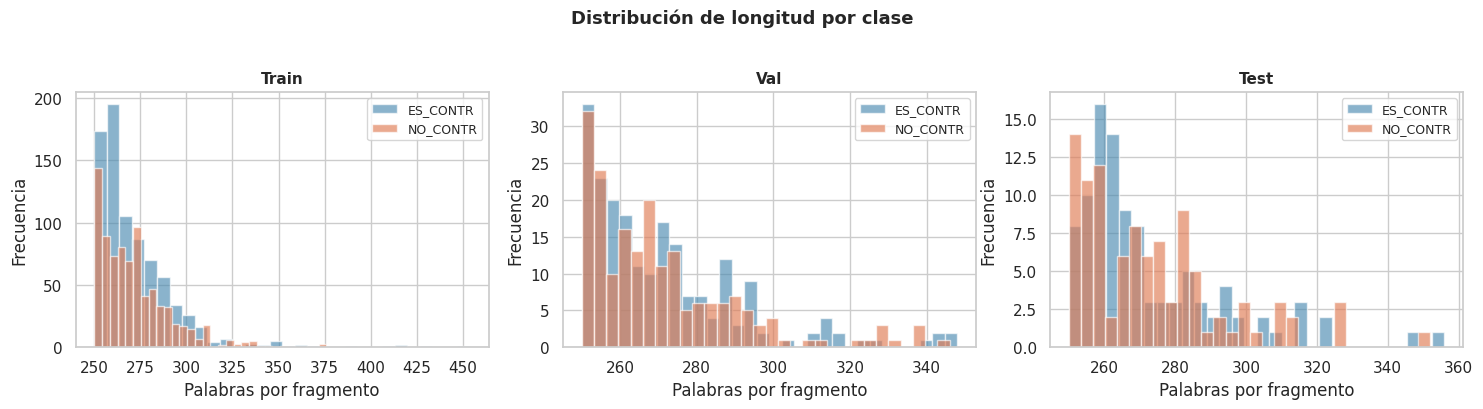


Estadísticas de longitud (train) por clase:
          count   mean   std    min    25%    50%    75%    max
a1_class                                                       
0         806.0  271.6  19.3  250.0  257.0  267.0  280.8  376.0
1         794.0  271.9  23.1  250.0  257.0  265.0  280.0  454.0


In [7]:
# ── Longitud en palabras ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (df, name) in zip(axes, [(df_train,"Train"), (df_val,"Val"), (df_test,"Test")]):
    for lv, ln, col in [(1,"ES_CONTR","#4c8bb1"), (0,"NO_CONTR","#e07b54")]:
        ax.hist(df[df["a1_class"]==lv]["word_count"], bins=30,
                alpha=0.65, label=ln, color=col, edgecolor="white")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Palabras por fragmento")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)

plt.suptitle("Distribución de longitud por clase", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nEstadísticas de longitud (train) por clase:")
print(df_train.groupby("a1_class")["word_count"].describe().round(1).to_string())

In [8]:
# ── Verificación visual: ¿qué texto ve el modelo? ────────────────────────────
# El modelo recibe SOLO el texto crudo. Sin prefijos ni metadatos.
print("="*65)
print("  EJEMPLO DE ENTRADA AL MODELO (solo texto, sin metadatos)")
print("="*65)

for label_val, label_name in [(1, "ES_CONTRIBUCION"), (0, "NO_ES_CONTRIBUCION")]:
    sample = df_train[df_train["a1_class"] == label_val].iloc[0]
    print(f"\n  Etiqueta: {label_name}")
    print(f"  Palabras: {sample['word_count']}")
    print(f"  Texto (primeros 300 chars):")
    print(f"  {str(sample['text'])[:300]}...")
    print()

  EJEMPLO DE ENTRADA AL MODELO (solo texto, sin metadatos)

  Etiqueta: ES_CONTRIBUCION
  Palabras: 287
  Texto (primeros 300 chars):
  Palimpsesto Vol. X, No 13 enero-junio, 2018: 90-102 Universidad de Santiago de Chile, ISSN 0718-5898 90 La larga tarea de reorganizar las comunidades de base. El movimiento de pobladores de Santiago entre dictadura cívico-militar y democracia neoliberal 1982-1999 The long work of reorganize the popu...


  Etiqueta: NO_ES_CONTRIBUCION
  Palabras: 274
  Texto (primeros 300 chars):
  Además, explica que el innatismo del lenguaje se concreta diciendo que todos nacen con un constructo interno, un esquema innato específicamente humano y genéticamente hereditario que él lo llama LAD Dispositivo de Adquisición del Lenguaje. Este mecanismo tiene como contenido un conjunto de principio...



---
## 4. Preparación del dataset para SciBETO (A5)

El modelo recibe **únicamente el texto** del fragmento.  
No se agrega ningún prefijo de metadatos — el encoder aprende del contenido semántico.

In [9]:
from torch.utils.data import Dataset
from transformers import AutoTokenizer

# ── Hiperparámetros ────────────────────────────────────────────────────────────
ENCODER_CONFIG = {
    "max_length"   : 512,   # máximo de tokens de SciBETO
    "batch_size"   : 8,     # tamaño de lote
    "learning_rate": 1e-5,  # lr estándar para fine-tuning BERT
    "num_epochs"   : 4,     # máximo de épocas (early stopping puede parar antes)
    "weight_decay" : 0.01,  # regularización L2
    "warmup_ratio" : 0.10,  # 10% de pasos con lr creciente (evita divergencia inicial)
}


class ContrDataset(Dataset):
    """
    Dataset PyTorch para clasificación binaria de contribuciones.

    Recibe un DataFrame con columnas:
      - 'text'    : el fragmento de texto (string)
      - 'a1_class': la etiqueta binaria (int 0 o 1)

    El tokenizador convierte el texto en input_ids y attention_mask,
    que son los tensores que SciBETO entiende.
    """

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int):
        self.labels     = df["a1_class"].tolist()
        # Solo el texto — sin prefijos de ningún tipo
        self.texts      = df["text"].astype(str).tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_length,
            padding        = "max_length",  # rellena hasta max_length con [PAD]
            truncation     = True,           # corta si supera max_length
            return_tensors = "pt",
        )
        return {
            "input_ids"      : enc["input_ids"].squeeze(),
            "attention_mask" : enc["attention_mask"].squeeze(),
            "labels"         : torch.tensor(self.labels[idx], dtype=torch.long),
        }


# ── Verificación rápida ────────────────────────────────────────────────────────
print("Cargando tokenizador de SciBETO-large para verificación...")
tok_check  = AutoTokenizer.from_pretrained("Flaglab/SciBETO-large")
sample_row = df_train.iloc[0]
sample_txt = str(sample_row["text"])
n_tokens   = len(tok_check(sample_txt, truncation=True, max_length=512)["input_ids"])

print(f"\nEjemplo de entrada al modelo (texto puro):")
print(f"  {sample_txt[:250]}...")
print(f"\n  Tokens generados : {n_tokens} / {ENCODER_CONFIG['max_length']}")
print(f"  Etiqueta         : {sample_row['a1_label']} (a1_class={sample_row['a1_class']})")
print(f"\n✓ El modelo solo ve el texto. Sin metadatos, sin prefijos.")

Cargando tokenizador de SciBETO-large para verificación...

Ejemplo de entrada al modelo (texto puro):
  Palimpsesto Vol. X, No 13 enero-junio, 2018: 90-102 Universidad de Santiago de Chile, ISSN 0718-5898 90 La larga tarea de reorganizar las comunidades de base. El movimiento de pobladores de Santiago entre dictadura cívico-militar y democracia neolibe...

  Tokens generados : 400 / 512
  Etiqueta         : ES_CONTRIBUCION (a1_class=1)

✓ El modelo solo ve el texto. Sin metadatos, sin prefijos.


---
## 5. A5 — Fine-tuning de SciBETO-large

**¿Por qué SciBETO?** Es un encoder RoBERTa preentrenado exclusivamente en texto científico
en español (Flaglab/SciBETO-large). Esto lo hace más adecuado que BERT genérico para este dominio.

**¿Qué hace el fine-tuning?** Se añade una capa de clasificación sobre el token `[CLS]`
de SciBETO y se ajustan todos los parámetros del modelo con los datos de entrenamiento.

**Métrica de selección del mejor modelo:** F1 Macro en validación (no accuracy, porque el
dataset está balanceado artificialmente y accuracy no discrimina bien entre clases).

In [10]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score
)
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)


def compute_metrics(eval_pred):
    """
    Métricas calculadas en cada época de validación.
    El Trainer las reporta automáticamente a W&B.
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(
        torch.tensor(logits, dtype=torch.float32), dim=-1
    ).numpy()[:, 1]
    try:
        auc = roc_auc_score(labels, probs)
    except Exception:
        auc = float("nan")
    return {
        "accuracy"  : float(accuracy_score(labels, preds)),
        "f1"        : float(f1_score(labels, preds, zero_division=0)),
        "precision" : float(precision_score(labels, preds, zero_division=0)),
        "recall"    : float(recall_score(labels, preds, zero_division=0)),
        "auc"       : float(auc),
    }


def train_encoder(
    model_name : str,
    df_train   : pd.DataFrame,
    df_val     : pd.DataFrame,
    config     : dict,
    run_name   : str,
    output_dir : str,
):
    """
    Entrena un encoder de clasificación binaria y lo registra en W&B.

    Parámetros:
      model_name  — nombre del modelo en HuggingFace Hub
      df_train    — DataFrame con columnas 'text' y 'a1_class'
      df_val      — idem, para validación por época
      config      — hiperparámetros (ENCODER_CONFIG)
      run_name    — nombre que aparece en W&B
      output_dir  — carpeta donde se guarda el mejor checkpoint

    Retorna: (trainer, tokenizer, model)
    """
    print(f"\n{'='*60}")
    print(f"  Modelo    : {model_name}")
    print(f"  Run W&B   : {run_name}")
    print(f"  Train     : {len(df_train):,} | Val: {len(df_val):,}")
    print(f"  Input     : solo texto (sin metadatos)")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels = 2,
        id2label   = {0: "NO_ES_CONTRIBUCION", 1: "ES_CONTRIBUCION"},
        label2id   = {"NO_ES_CONTRIBUCION": 0, "ES_CONTRIBUCION": 1},
    )

    train_ds = ContrDataset(df_train, tokenizer, config["max_length"])
    val_ds   = ContrDataset(df_val,   tokenizer, config["max_length"])

    steps_ep     = len(train_ds) // config["batch_size"]
    warmup_steps = int(steps_ep * config["num_epochs"] * config["warmup_ratio"])

    training_args = TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = config["num_epochs"],
        per_device_train_batch_size = config["batch_size"],
        per_device_eval_batch_size  = config["batch_size"] * 2,
        learning_rate               = config["learning_rate"],
        weight_decay                = config["weight_decay"],
        warmup_steps                = warmup_steps,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "f1",
        greater_is_better           = True,
        fp16                        = torch.cuda.is_available(),
        logging_steps               = 50,
        report_to                   = "wandb",
        run_name                    = run_name,
        seed                        = SEED,
    )

    # Inicializar el run W&B con group="task2" ANTES de trainer.train()
    # Sin esto, HuggingFace crea el run en un proyecto llamado "huggingface"
    wandb.init(
        project = WB_PROJECT,
        entity  = WB_ENTITY,
        group   = WB_GROUP,
        name    = run_name,
        tags    = ["task2", "encoder", "texto-puro", model_name.split("/")[-1]],
        config  = {
            **config,
            "model_name"  : model_name,
            "train_size"  : len(df_train),
            "val_size"    : len(df_val),
            "input_type"  : "texto_puro",  # sin metadatos
        },
        reinit = True,
    )

    trainer = Trainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    val_res = trainer.evaluate()
    print(f"\n  → Val F1: {val_res['eval_f1']:.4f} | Accuracy: {val_res['eval_accuracy']:.4f}")

    wandb.finish()
    return trainer, tokenizer, model


# Diccionario que acumula resultados de todos los modelos para comparación final
results = {}

In [11]:
# ── A5: Fine-tuning SciBETO-large ─────────────────────────────────────────────
# Tiempo estimado: ~15-20 min en GPU T4, ~8-10 min en A100
scibeto_trainer, scibeto_tok, scibeto_model = train_encoder(
    model_name = "Flaglab/SciBETO-large",
    df_train   = df_train,
    df_val     = df_val,
    config     = ENCODER_CONFIG,
    run_name   = "task2-scibeto-v3",
    output_dir = "/tmp/scibeto_task2",  # ← en Drive
)


  Modelo    : Flaglab/SciBETO-large
  Run W&B   : task2-scibeto-v3
  Train     : 1,600 | Val: 400
  Input     : solo texto (sin metadatos)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Flaglab/SciBETO-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,0.464970,0.467688,0.780000,0.773196,0.824176,0.728155,0.866392
2,0.282055,0.569521,0.777500,0.774684,0.809524,0.742718,0.874174
3,0.194763,0.828864,0.785000,0.783920,0.812500,0.757282,0.877077
4,0.126455,0.995724,0.787500,0.784810,0.820106,0.752427,0.871172


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  → Val F1: 0.7848 | Accuracy: 0.7875


eval/accuracy,▃▁▆██
eval/auc,▁▆█▄▄
eval/f1,▁▂▇██
eval/loss,▁▂▆██
eval/precision,█▁▂▆▆
eval/recall,▁▅█▇▇
eval/runtime,▁▁▂▁█
eval/samples_per_second,▇█▇█▁
eval/steps_per_second,▇█▇█▁
train/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▆▆▆▇▇█████
+4,...


### 5.1 Curvas de entrenamiento

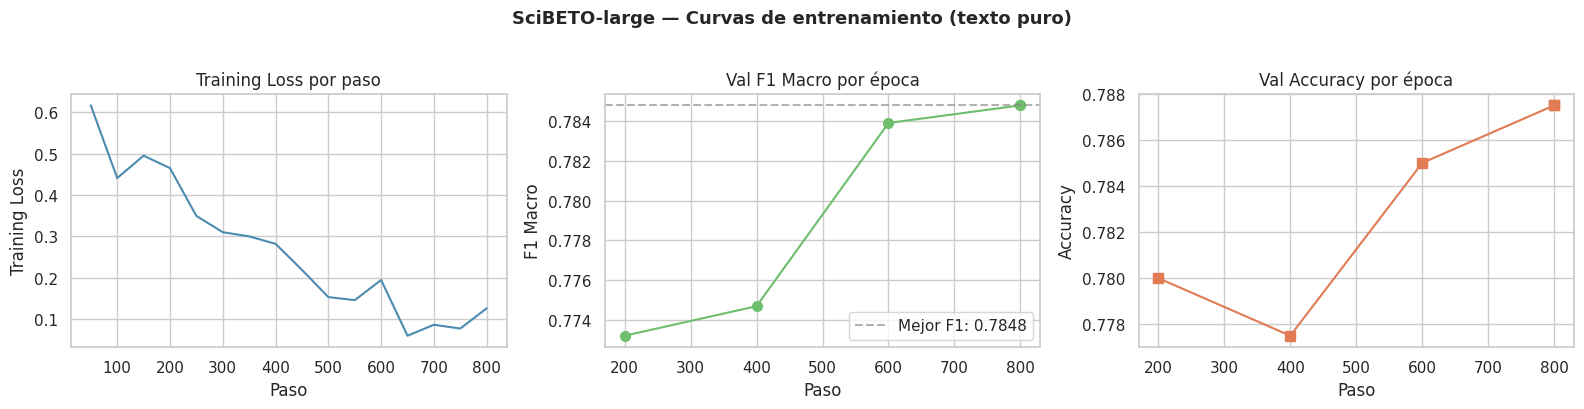

In [12]:
# ── Curvas de loss y F1 por época ────────────────────────────────────────────
history    = scibeto_trainer.state.log_history
train_loss = [(h["step"], h["loss"])    for h in history if "loss"    in h]
eval_f1    = [(h["step"], h["eval_f1"]) for h in history if "eval_f1" in h]
eval_acc   = [(h["step"], h["eval_accuracy"]) for h in history if "eval_accuracy" in h]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if train_loss:
    steps, losses = zip(*train_loss)
    axes[0].plot(steps, losses, color="#4c8bb1", linewidth=1.5)
    axes[0].set_xlabel("Paso"); axes[0].set_ylabel("Training Loss")
    axes[0].set_title("Training Loss por paso")

if eval_f1:
    steps, f1s = zip(*eval_f1)
    best_f1    = max(f1s)
    axes[1].plot(steps, f1s, color="#6dbf6d", marker="o", linewidth=1.5, markersize=7)
    axes[1].axhline(best_f1, color="gray", linestyle="--", alpha=0.6,
                    label=f"Mejor F1: {best_f1:.4f}")
    axes[1].set_xlabel("Paso"); axes[1].set_ylabel("F1 Macro")
    axes[1].set_title("Val F1 Macro por época")
    axes[1].legend()

if eval_acc:
    steps, accs = zip(*eval_acc)
    axes[2].plot(steps, accs, color="#e07b54", marker="s", linewidth=1.5, markersize=7)
    axes[2].set_xlabel("Paso"); axes[2].set_ylabel("Accuracy")
    axes[2].set_title("Val Accuracy por época")

plt.suptitle("SciBETO-large — Curvas de entrenamiento (texto puro)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/tmp/curvas_scibeto.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Evaluación en el conjunto de referencia

> `anotacion_referencia.csv` contiene fragmentos anotados manualmente.
> **Nunca se usó en entrenamiento ni validación.**  
> Es el único conjunto que mide la capacidad real de generalización del modelo.


  SciBETO-large-3
  Test: anotacion_referencia.csv (n=200)
  F1 Macro=0.8485 | Accuracy=0.8500 | AUC=0.9444
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.94      0.75      0.83       100
   ES_CONTRIBUCION       0.79      0.95      0.86       100

          accuracy                           0.85       200
         macro avg       0.86      0.85      0.85       200
      weighted avg       0.86      0.85      0.85       200



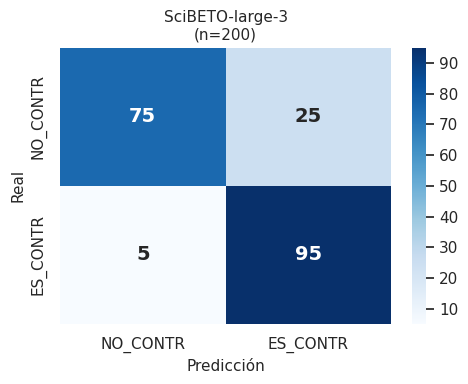

test/accuracy,▁▁
test/auc,▁▁
test/f1,▁
test/f1_macro,▁
test/f1_negativos,▁
test/f1_positivos,▁
test/loss,▁
test/precision,▁
test/precision_pos,▁
test/recall,▁
+4,...


In [13]:
def evaluate_on_test(
    trainer,
    tokenizer,
    df_test    : pd.DataFrame,
    model_label: str,
    run_name   : str,
    cmap       : str = "Blues",
) -> dict:

    # ── W&B se inicia ANTES de trainer.predict() ──────────────────────────────
    # trainer.predict() internamente intenta loguear métricas a W&B.
    # Si no hay un run activo en ese momento, lanza el error que ves.
    wandb.init(
        project = WB_PROJECT, entity = WB_ENTITY,
        group   = WB_GROUP,
        name    = f"eval-test-{run_name}",
        tags    = ["task2", "evaluacion", "anotacion-referencia", model_label],
        config  = {
            "modelo"    : model_label,
            "eval_set"  : "anotacion_referencia",
            "n_test"    : len(df_test),
            "input_type": "texto_puro",
        },
        reinit = True,
    )

    test_ds      = ContrDataset(df_test, tokenizer, ENCODER_CONFIG["max_length"])
    preds_output = trainer.predict(test_ds)

    logits = preds_output.predictions
    labels = preds_output.label_ids
    preds  = np.argmax(logits, axis=-1)

    try:
        probs = torch.softmax(
            torch.tensor(logits, dtype=torch.float32), dim=-1
        ).numpy()[:, 1]
        auc = roc_auc_score(labels, probs)
    except Exception:
        probs = np.zeros(len(preds))
        auc   = float("nan")

    report = classification_report(
        labels, preds,
        target_names = ["NO_ES_CONTRIBUCION", "ES_CONTRIBUCION"],
        output_dict  = True,
    )

    metrics = {
        "model"         : model_label,
        "f1_macro"      : report["macro avg"]["f1-score"],
        "f1_positivos"  : report["ES_CONTRIBUCION"]["f1-score"],
        "recall_pos"    : report["ES_CONTRIBUCION"]["recall"],
        "precision_pos" : report["ES_CONTRIBUCION"]["precision"],
        "f1_negativos"  : report["NO_ES_CONTRIBUCION"]["f1-score"],
        "accuracy"      : report["accuracy"],
        "auc"           : auc,
    }

    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"  Test: anotacion_referencia.csv (n={len(df_test)})")
    print(f"  F1 Macro={metrics['f1_macro']:.4f} | Accuracy={metrics['accuracy']:.4f} | AUC={auc:.4f}")
    print(f"{'='*55}")
    print(classification_report(labels, preds,
          target_names=["NO_ES_CONTRIBUCION", "ES_CONTRIBUCION"]))

    wandb.log({f"test/{k}": v for k, v in metrics.items()
               if k != "model" and not (isinstance(v, float) and np.isnan(v))})

    cm  = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["NO_CONTR", "ES_CONTR"],
                yticklabels=["NO_CONTR", "ES_CONTR"], ax=ax,
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)
    ax.set_title(f"{model_label}\n(n={len(df_test)})", fontsize=11)
    plt.tight_layout()
    wandb.log({"test/confusion_matrix": wandb.Image(fig)})
    plt.savefig(f"/tmp/cm_{run_name.replace(' ','_')}.png", dpi=150)
    plt.show()
    wandb.finish()

    return {
        "metrics": metrics,
        "preds"  : preds,
        "probs"  : probs,
        "labels" : labels,
        "report" : report,
    }


results["scibeto"] = evaluate_on_test(
    scibeto_trainer, scibeto_tok, df_test,
    model_label = "SciBETO-large-3",
    run_name    = "scibeto-large-3",
)

---
## 7. A6 — Inferencia con LLM open-weight: Llama 3.1 8B

Los LLMs se usan en **modo inferencia pura**, sin entrenamiento.  
Se comparan dos estrategias de prompting:
- **Zero-shot**: solo la definición del problema, sin ejemplos
- **Few-shot**: 4 ejemplos cuidadosamente seleccionados

> Los ejemplos few-shot NO contienen los patrones lingüísticos usados para
> construir el dataset (`proponemos`, `nuestra propuesta`, etc.).
> Esto garantiza que el LLM no aprenda el mismo atajo superficial que queremos evitar.

In [14]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_compute_dtype    = torch.float16,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_use_double_quant = True,
)

LLM_MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"

print(f"Cargando {LLM_MODEL_ID} en cuantización 4-bit NF4...")
llm_tok = AutoTokenizer.from_pretrained(LLM_MODEL_ID, token=HF_TOKEN)
llm_mdl = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_ID,
    quantization_config = bnb_config,
    device_map          = "auto",
    token               = HF_TOKEN,
)
llm_mdl.eval()
print("✓ Llama 3.1 8B cargado")

Cargando meta-llama/Meta-Llama-3.1-8B-Instruct en cuantización 4-bit NF4...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

✓ Llama 3.1 8B cargado


In [15]:
# ── Definición de prompts ─────────────────────────────────────────────────────

SYSTEM_PROMPT = """Eres un experto en análisis de texto científico en español.
Tu tarea es determinar si un fragmento de un artículo académico expresa
una contribución científica original del trabajo.

Una CONTRIBUCIÓN CIENTÍFICA es cuando el texto describe:
- Un método, modelo, sistema o framework nuevo desarrollado por los autores
- Resultados que demuestran superioridad cuantificada sobre trabajos anteriores
- Un recurso construido por los autores (corpus, dataset, herramienta)
- Un hallazgo original que avanza el conocimiento en el campo

NO es una contribución cuando el texto:
- Describe trabajos o resultados de otros autores
- Explica metodología estándar del campo sin novedad propia
- Presenta resultados puramente descriptivos sin comparación
- Define conceptos o introduce el problema sin aportar solución
- Es portada, encabezado, aviso legal o texto institucional

Responde ÚNICAMENTE con:
- ES_CONTRIBUCION
- NO_ES_CONTRIBUCION

Sin explicaciones adicionales."""

ZERO_SHOT_TEMPLATE = """Fragmento de texto científico en español:
{text}

¿Este fragmento expresa una contribución científica original del trabajo?"""

# Ejemplos escritos SIN los patrones del pipeline
# (sin "proponemos", "nuestra propuesta", "se introduce un nuevo", etc.)
FEW_SHOT_EXAMPLES = [
    {
        "text": ("Los experimentos sobre cinco conjuntos de datos muestran que "
                 "el sistema desarrollado reduce el tiempo de procesamiento en un 34% "
                 "respecto a las líneas base de la literatura, con niveles equivalentes "
                 "de exactitud. Este resultado tiene implicaciones directas para "
                 "aplicaciones con recursos computacionales limitados."),
        "label": "ES_CONTRIBUCION",
    },
    {
        "text": ("El análisis estadístico reveló diferencias significativas entre los "
                 "grupos (p < 0.001). Los valores medios oscilaron entre 23.4 y 47.8. "
                 "Se empleó la corrección de Bonferroni para comparaciones múltiples, "
                 "siguiendo el procedimiento estándar de la literatura metodológica."),
        "label": "NO_ES_CONTRIBUCION",
    },
    {
        "text": ("A partir de los criterios definidos se construyó una base de anotaciones "
                 "con 12.000 fragmentos de texto académico en español, distribuidos en "
                 "ocho categorías retóricas. Cada fragmento fue revisado por dos evaluadores "
                 "independientes, alcanzando un kappa de 0.78."),
        "label": "ES_CONTRIBUCION",
    },
    {
        "text": ("Los fundamentos del aprendizaje profundo fueron desarrollados en las "
                 "últimas décadas. LeCun et al. introdujeron las redes convolucionales "
                 "para reconocimiento de imágenes, mientras que Hochreiter y Schmidhuber "
                 "establecieron las bases de las redes LSTM para secuencias."),
        "label": "NO_ES_CONTRIBUCION",
    },
]

def build_few_shot_block(examples):
    lines = []
    for i, ex in enumerate(examples, 1):
        lines.append(f"Ejemplo {i}:\nTexto: {ex['text']}\nClasificación: {ex['label']}")
    return "\n\n".join(lines)

FEW_SHOT_BLOCK = build_few_shot_block(FEW_SHOT_EXAMPLES)

FEW_SHOT_TEMPLATE = """A continuación se muestran ejemplos de clasificación:

{examples}

Ahora clasifica el siguiente fragmento:
{text}

¿Este fragmento expresa una contribución científica original del trabajo?"""

print("✓ Prompts definidos")
print(f"  Zero-shot : instrucción + texto (sin ejemplos)")
print(f"  Few-shot  : instrucción + {len(FEW_SHOT_EXAMPLES)} ejemplos sin patrones del pipeline + texto")

✓ Prompts definidos
  Zero-shot : instrucción + texto (sin ejemplos)
  Few-shot  : instrucción + 4 ejemplos sin patrones del pipeline + texto


  Llama-3.1-8B-zero-shot: 100%|██████████| 200/200 [02:22<00:00,  1.40it/s]



  Llama-3.1-8B-zero-shot  |  F1 Macro=0.4857
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.53      0.94      0.68       100
   ES_CONTRIBUCION       0.75      0.18      0.29       100

          accuracy                           0.56       200
         macro avg       0.64      0.56      0.49       200
      weighted avg       0.64      0.56      0.49       200



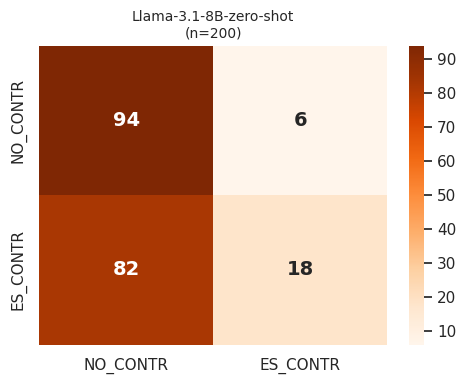

test/accuracy,▁
test/f1_macro,▁
test/f1_negativos,▁
test/f1_positivos,▁
test/precision_pos,▁
test/recall_pos,▁
test/accuracy,0.56
test/f1_macro,0.48574
test/f1_negativos,0.68116
test/f1_positivos,0.29032
test/precision_pos,0.75


  Llama-3.1-8B-few-shot: 100%|██████████| 200/200 [02:30<00:00,  1.33it/s]



  Llama-3.1-8B-few-shot  |  F1 Macro=0.4658
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.53      0.98      0.69       100
   ES_CONTRIBUCION       0.88      0.14      0.24       100

          accuracy                           0.56       200
         macro avg       0.70      0.56      0.47       200
      weighted avg       0.70      0.56      0.47       200



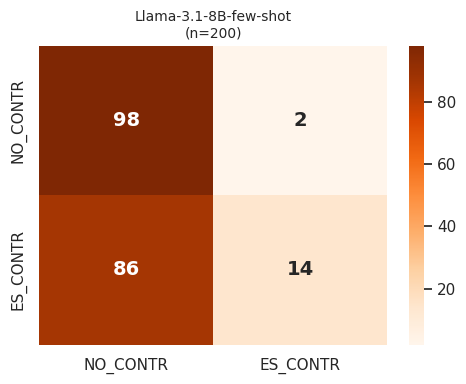

test/accuracy,▁
test/f1_macro,▁
test/f1_negativos,▁
test/f1_positivos,▁
test/precision_pos,▁
test/recall_pos,▁
test/accuracy,0.56
test/f1_macro,0.46576
test/f1_negativos,0.69014
test/f1_positivos,0.24138
test/precision_pos,0.875


In [17]:
def run_llm_inference(
    model,
    tokenizer,
    df           : pd.DataFrame,
    prompt_style : str = "zero_shot",
    run_name     : str = "",
    max_new_tokens: int = 12,
) -> dict:
    """
    Ejecuta inferencia con LLM sobre el conjunto de referencia.
    Temperatura 0 para reproducibilidad (greedy decoding).
    """
    device = next(model.parameters()).device
    preds, labels_list = [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"  {run_name}"):
        text = str(row.get("text", ""))[:1800]

        user_msg = (
            ZERO_SHOT_TEMPLATE.format(text=text) if prompt_style == "zero_shot"
            else FEW_SHOT_TEMPLATE.format(examples=FEW_SHOT_BLOCK, text=text)
        )

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_msg},
        ]

        # ── FIX 1: apply_chat_template puede devolver BatchEncoding o tensor ──────
        # Según la versión de transformers el tipo de retorno varía.
        # Extraemos input_ids de forma segura en ambos casos.
        encoded = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt"
        )
        if hasattr(encoded, "input_ids"):
            input_ids = encoded["input_ids"].to(device)
        else:
            input_ids = encoded.to(device)  # ya es un tensor directo

        prompt_len = input_ids.shape[-1]  # guardamos longitud ANTES de generar

        # ── FIX 2: quitar temperature cuando do_sample=False ─────────────────────
        # Con greedy decoding (do_sample=False) temperature no aplica.
        # Las versiones nuevas de transformers lanzan error si se incluye.
        with torch.no_grad():
            output = model.generate(
                input_ids,
                max_new_tokens = max_new_tokens,
                do_sample      = False,       # greedy — reproducible
                pad_token_id   = tokenizer.eos_token_id,
            )

        # Decodificar solo los tokens nuevos (excluir el prompt de entrada)
        raw = tokenizer.decode(
            output[0][prompt_len:], skip_special_tokens=True
        ).strip().upper()

        # Mapeo a etiqueta binaria
        if "NO_ES" in raw or "NO ES" in raw:
            preds.append(0)
        elif "ES_CONTRIBUCION" in raw or "ES CONTRIBUCION" in raw:
            preds.append(1)
        else:
            preds.append(0)  # fallback conservador

        labels_list.append(int(row["a1_class"]))

    preds_arr  = np.array(preds)
    labels_arr = np.array(labels_list)

    report = classification_report(
        labels_arr, preds_arr,
        target_names = ["NO_ES_CONTRIBUCION", "ES_CONTRIBUCION"],
        output_dict  = True,
    )
    metrics = {
        "model"         : run_name,
        "f1_macro"      : report["macro avg"]["f1-score"],
        "f1_positivos"  : report["ES_CONTRIBUCION"]["f1-score"],
        "recall_pos"    : report["ES_CONTRIBUCION"]["recall"],
        "precision_pos" : report["ES_CONTRIBUCION"]["precision"],
        "f1_negativos"  : report["NO_ES_CONTRIBUCION"]["f1-score"],
        "accuracy"      : report["accuracy"],
        "auc"           : float("nan"),  # sin probabilidades en greedy decoding
    }

    print(f"\n{'='*55}")
    print(f"  {run_name}  |  F1 Macro={metrics['f1_macro']:.4f}")
    print(f"{'='*55}")
    print(classification_report(labels_arr, preds_arr,
          target_names=["NO_ES_CONTRIBUCION", "ES_CONTRIBUCION"]))

    # W&B
    wandb.init(
        project = WB_PROJECT, entity = WB_ENTITY,
        group   = WB_GROUP,
        name    = f"eval-test-{run_name}",
        tags    = ["task2", "llm", "evaluacion", "anotacion-referencia", prompt_style],
        config  = {"modelo": run_name, "prompt_style": prompt_style,
                   "n_test": len(df), "eval_set": "anotacion_referencia"},
        reinit  = True,
    )
    wandb.log({f"test/{k}": v for k, v in metrics.items()
               if k != "model" and not (isinstance(v, float) and np.isnan(v))})

    cm  = confusion_matrix(labels_arr, preds_arr)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=["NO_CONTR", "ES_CONTR"],
                yticklabels=["NO_CONTR", "ES_CONTR"], ax=ax,
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(f"{run_name}\n(n={len(df)})", fontsize=10)
    plt.tight_layout()
    wandb.log({"test/confusion_matrix": wandb.Image(fig)})
    plt.savefig(f"/tmp/cm_{run_name.replace(' ','_')}.png", dpi=150)
    plt.show()
    wandb.finish()

    return {"metrics": metrics, "preds": preds_arr, "labels": labels_arr, "report": report}


# ── Ejecutar A6 ───────────────────────────────────────────────────────────────
results["llama_zero"] = run_llm_inference(
    llm_mdl, llm_tok, df_test,
    prompt_style="zero_shot", run_name="Llama-3.1-8B-zero-shot"
)

results["llama_few"] = run_llm_inference(
    llm_mdl, llm_tok, df_test,
    prompt_style="few_shot", run_name="Llama-3.1-8B-few-shot"
)

---
## 8. A7 — LLM comercial vía API: GPT-4o

Misma estrategia de prompting que Llama para comparación justa.  
Se evalúa solo sobre `anotacion_referencia.csv` (200 fragmentos).

  GPT-4o-zero-shot: 100%|██████████| 200/200 [03:13<00:00,  1.03it/s]



=======================================================  GPT-4o-zero-shot
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.52      0.99      0.68       100
   ES_CONTRIBUCION       0.89      0.08      0.15       100

          accuracy                           0.54       200
         macro avg       0.70      0.54      0.41       200
      weighted avg       0.70      0.54      0.41       200



wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


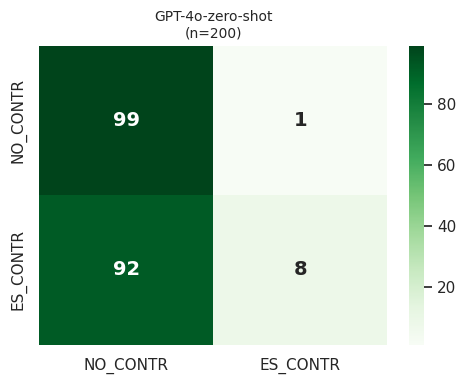

test/accuracy,▁
test/f1_macro,▁
test/f1_negativos,▁
test/f1_positivos,▁
test/precision_pos,▁
test/recall_pos,▁
test/accuracy,0.535
test/f1_macro,0.4136
test/f1_negativos,0.68041
test/f1_positivos,0.14679
test/precision_pos,0.88889


  GPT-4o-few-shot: 100%|██████████| 200/200 [05:24<00:00,  1.62s/it]



=======================================================  GPT-4o-few-shot
                    precision    recall  f1-score   support

NO_ES_CONTRIBUCION       0.52      1.00      0.68       100
   ES_CONTRIBUCION       1.00      0.06      0.11       100

          accuracy                           0.53       200
         macro avg       0.76      0.53      0.40       200
      weighted avg       0.76      0.53      0.40       200



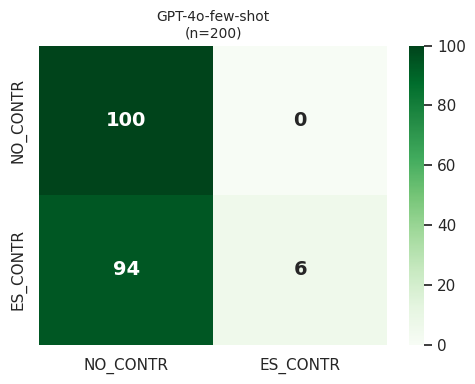

test/accuracy,▁
test/f1_macro,▁
test/f1_negativos,▁
test/f1_positivos,▁
test/precision_pos,▁
test/recall_pos,▁
test/accuracy,0.53
test/f1_macro,0.39674
test/f1_negativos,0.68027
test/f1_positivos,0.11321
test/precision_pos,1


In [18]:
from openai import OpenAI

def run_gpt_inference(
    df           : pd.DataFrame,
    api_key      : str,
    model_id     : str = "gpt-4o",
    prompt_style : str = "few_shot",
    run_name     : str = "GPT-4o-few-shot",
) -> dict:
    """Evalúa GPT-4o sobre anotacion_referencia.csv con manejo de errores."""
    if not api_key:
        print(f"⚠️  OPENAI_API_KEY no disponible. Saltando {run_name}.")
        return {}

    client = OpenAI(api_key=api_key)
    preds, labels_list = [], []

    for idx, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc=f"  {run_name}")):
        text = str(row.get("text", ""))[:2000]
        user_msg = (
            ZERO_SHOT_TEMPLATE.format(text=text) if prompt_style == "zero_shot"
            else FEW_SHOT_TEMPLATE.format(examples=FEW_SHOT_BLOCK, text=text)
        )

        try:
            response = client.chat.completions.create(
                model       = model_id,
                messages    = [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": user_msg},
                ],
                max_tokens  = 10,
                temperature = 0.0,
                seed        = SEED,
            )
            raw = response.choices[0].message.content.strip().upper()
        except Exception as e:
            print(f"  Error fragmento {idx}: {e}")
            raw = ""

        if "NO_ES" in raw or "NO ES" in raw:
            preds.append(0)
        elif "ES_CONTRIBUCION" in raw or "ES CONTRIBUCION" in raw:
            preds.append(1)
        else:
            preds.append(0)
        labels_list.append(int(row["a1_class"]))

        if (idx + 1) % 10 == 0:
            time.sleep(0.3)  # evitar rate limit

    preds_arr  = np.array(preds)
    labels_arr = np.array(labels_list)

    report = classification_report(
        labels_arr, preds_arr,
        target_names=["NO_ES_CONTRIBUCION", "ES_CONTRIBUCION"],
        output_dict=True,
    )
    metrics = {
        "model"         : run_name,
        "f1_macro"      : report["macro avg"]["f1-score"],
        "f1_positivos"  : report["ES_CONTRIBUCION"]["f1-score"],
        "recall_pos"    : report["ES_CONTRIBUCION"]["recall"],
        "precision_pos" : report["ES_CONTRIBUCION"]["precision"],
        "f1_negativos"  : report["NO_ES_CONTRIBUCION"]["f1-score"],
        "accuracy"      : report["accuracy"],
        "auc"           : float("nan"),
    }

    print(f"\n{'='*55}  {run_name}")
    print(classification_report(labels_arr, preds_arr,
          target_names=["NO_ES_CONTRIBUCION", "ES_CONTRIBUCION"]))

    wandb.init(
        project=WB_PROJECT, entity=WB_ENTITY, group=WB_GROUP,
        name=f"eval-test-{run_name}",
        tags=["task2","commercial","gpt","evaluacion","anotacion-referencia",prompt_style],
        config={"modelo":run_name, "prompt_style":prompt_style, "n_test":len(df)},
        reinit=True,
    )
    wandb.log({f"test/{k}": v for k, v in metrics.items()
               if k != "model" and not (isinstance(v, float) and np.isnan(v))})

    cm = confusion_matrix(labels_arr, preds_arr)
    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["NO_CONTR","ES_CONTR"],
                yticklabels=["NO_CONTR","ES_CONTR"], ax=ax,
                annot_kws={"size":14,"weight":"bold"})
    ax.set_title(f"{run_name}\n(n={len(df)})", fontsize=10)
    plt.tight_layout()
    wandb.log({"test/confusion_matrix": wandb.Image(fig)})
    plt.show()
    wandb.finish()

    return {"metrics": metrics, "preds": preds_arr, "labels": labels_arr, "report": report}


# ── Ejecutar A7 ───────────────────────────────────────────────────────────────
results["gpt4o_zero"] = run_gpt_inference(
    df_test, OPENAI_API_KEY, model_id="gpt-4o",
    prompt_style="zero_shot", run_name="GPT-4o-zero-shot"
)
results["gpt4o_few"] = run_gpt_inference(
    df_test, OPENAI_API_KEY, model_id="gpt-4o",
    prompt_style="few_shot", run_name="GPT-4o-few-shot"
)

---
## 9. A10 — Análisis comparativo

### 9.1 Tabla resumen

In [19]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
rows = [res["metrics"] for res in results.values() if res and "metrics" in res]
df_summary = pd.DataFrame(rows).set_index("model").sort_values("f1_macro", ascending=False)

print("\n" + "="*75)
print(f"  RESULTADOS — anotacion_referencia.csv  (n={len(df_test)})")
print("="*75)
print(df_summary.round(4).to_string())
print("="*75)


  RESULTADOS — anotacion_referencia.csv  (n=200)
                        f1_macro  f1_positivos  recall_pos  precision_pos  f1_negativos  accuracy     auc
model                                                                                                    
SciBETO-large-3           0.8485        0.8636        0.95         0.7917        0.8333     0.850  0.9444
Llama-3.1-8B-zero-shot    0.4857        0.2903        0.18         0.7500        0.6812     0.560     NaN
Llama-3.1-8B-few-shot     0.4658        0.2414        0.14         0.8750        0.6901     0.560     NaN
GPT-4o-zero-shot          0.4136        0.1468        0.08         0.8889        0.6804     0.535     NaN
GPT-4o-few-shot           0.3967        0.1132        0.06         1.0000        0.6803     0.530     NaN


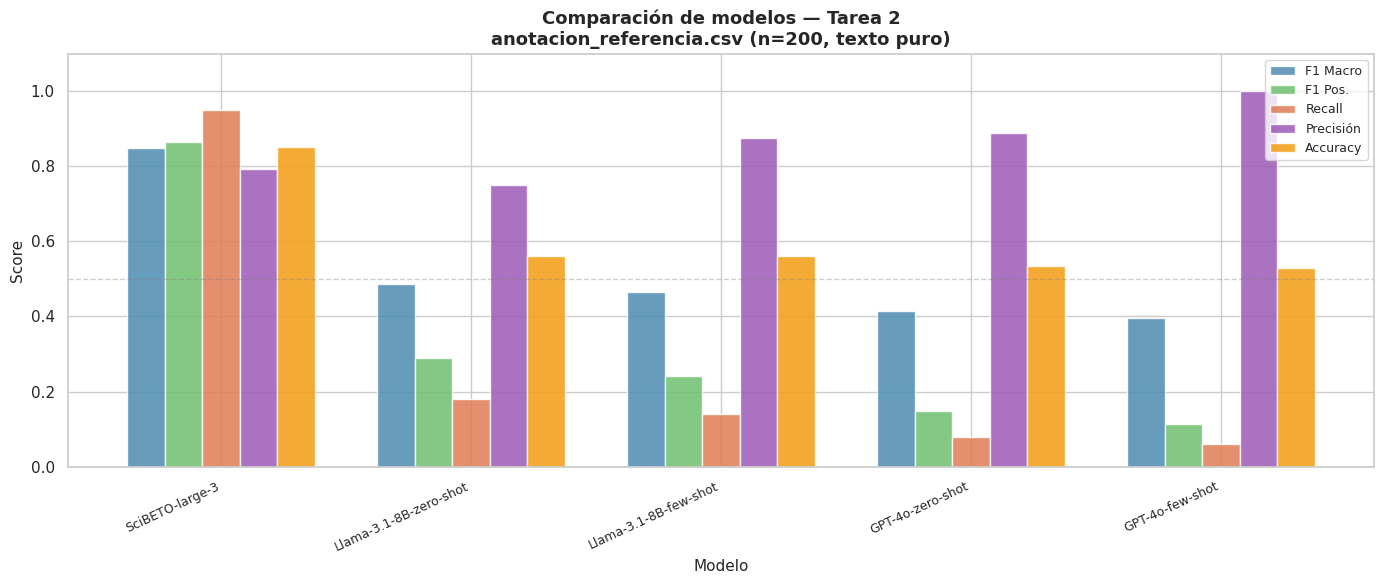

resumen/GPT_4o_few_shot/accuracy,▁
resumen/GPT_4o_few_shot/f1_macro,▁
resumen/GPT_4o_few_shot/f1_positivos,▁
resumen/GPT_4o_few_shot/precision_pos,▁
resumen/GPT_4o_few_shot/recall_pos,▁
resumen/GPT_4o_zero_shot/accuracy,▁
resumen/GPT_4o_zero_shot/f1_macro,▁
resumen/GPT_4o_zero_shot/f1_positivos,▁
resumen/GPT_4o_zero_shot/precision_pos,▁
resumen/GPT_4o_zero_shot/recall_pos,▁
+15,...


In [20]:
# ── Gráfico comparativo ───────────────────────────────────────────────────────
metricas   = ["f1_macro", "f1_positivos", "recall_pos", "precision_pos", "accuracy"]
etiquetas  = ["F1 Macro", "F1 Pos.", "Recall", "Precisión", "Accuracy"]
colores    = ["#4c8bb1", "#6dbf6d", "#e07b54", "#9b59b6", "#f39c12"]

fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(df_summary))
width = 0.15

for i, (met, etq, col) in enumerate(zip(metricas, etiquetas, colores)):
    vals = [
        df_summary.loc[m, met] if not np.isnan(df_summary.loc[m, met]) else 0
        for m in df_summary.index
    ]
    ax.bar(x + i * width, vals, width, label=etq, color=col, alpha=0.85)

ax.set_xlabel("Modelo", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    f"Comparación de modelos — Tarea 2\nanotacion_referencia.csv (n={len(df_test)}, texto puro)",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_summary.index, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(loc="upper right", fontsize=9)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4, linewidth=1)
plt.tight_layout()
plt.savefig("/tmp/comparacion_t2.png", dpi=150, bbox_inches="tight")
plt.show()

# Registrar gráfico en W&B
wandb.init(
    project=WB_PROJECT, entity=WB_ENTITY, group=WB_GROUP,
    name="task2-resumen-comparativo",
    tags=["task2","resumen","comparacion"], reinit=True,
)
wandb.log({"resumen/comparacion_modelos": wandb.Image(fig)})
for m_key in df_summary.index:
    for met in metricas:
        val = df_summary.loc[m_key, met]
        if not np.isnan(val):
            safe = m_key.replace("-","_").replace(" ","_")
            wandb.log({f"resumen/{safe}/{met}": val})
wandb.finish()

### 9.2 Análisis cualitativo de errores (FP y FN)

In [21]:
def analyze_errors(result: dict, df_test: pd.DataFrame,
                   model_label: str, n_show: int = 3) -> pd.DataFrame:
    """
    Identifica Falsos Positivos y Falsos Negativos y analiza sus patrones.

    FP = el modelo dijo ES_CONTRIBUCION pero era NO_ES_CONTRIBUCION
         → el modelo fue engañado por el texto
    FN = el modelo dijo NO_ES_CONTRIBUCION pero era ES_CONTRIBUCION
         → el modelo no reconoció el aporte
    """
    if not result:
        return None

    preds  = result["preds"]
    labels = result["labels"]
    df_ev  = df_test.copy().reset_index(drop=True)
    df_ev["pred"]  = preds
    df_ev["label"] = labels

    fp_mask = (preds == 1) & (labels == 0)
    fn_mask = (preds == 0) & (labels == 1)
    df_ev["tipo"] = "Correcto"
    df_ev.loc[fp_mask, "tipo"] = "FP"
    df_ev.loc[fn_mask, "tipo"] = "FN"

    n_tp = ((preds==1)&(labels==1)).sum()
    n_tn = ((preds==0)&(labels==0)).sum()

    print(f"\n{'='*60}")
    print(f"  {model_label}")
    print(f"  TP={n_tp} | TN={n_tn} | FP={fp_mask.sum()} | FN={fn_mask.sum()}")

    print("\n  Longitud media (palabras) por tipo de predicción:")
    print(df_ev.groupby("tipo")["word_count"].agg(["mean","median","count"]).round(1).to_string())

    # Ejemplos representativos
    for tipo, titulo in [
        ("FP", "FALSOS POSITIVOS — predijo ES_CONTR pero era NO_ES_CONTR"),
        ("FN", "FALSOS NEGATIVOS — predijo NO_ES_CONTR pero era ES_CONTR"),
    ]:
        sub = df_ev[df_ev["tipo"] == tipo].head(n_show)
        if len(sub) == 0:
            continue
        print(f"\n  ── {titulo} ──")
        for i, (_, row) in enumerate(sub.iterrows(), 1):
            print(f"  #{i} | palabras={row['word_count']}")
            print(f"     {str(row['text'])[:280]}...")

    return df_ev


# Análisis de errores para los modelos disponibles
errores = {}
for key, label in [
    ("scibeto",    "SciBETO-large"),
    ("llama_few",  "Llama-3.1-8B few-shot"),
    ("gpt4o_few",  "GPT-4o few-shot"),
]:
    if key in results and results[key]:
        errores[key] = analyze_errors(results[key], df_test, label)


  SciBETO-large
  TP=95 | TN=75 | FP=25 | FN=5

  Longitud media (palabras) por tipo de predicción:
           mean  median  count
tipo                          
Correcto  272.6   266.0    170
FN        272.6   273.0      5
FP        273.9   269.0     25

  ── FALSOS POSITIVOS — predijo ES_CONTR pero era NO_ES_CONTR ──
  #1 | palabras=254
     xi El aislamiento de una estructura es la herramienta más potente de la ingeniería sísmica, basándose en la reducción de la demanda sísmica en lugar del incremento de la capacidad resistente de las estructuras, que consiste en desacoplar la estructura del suelo, que permite un co...
  #2 | palabras=303
     Desde las postrimerías de la campaña presidencial, la mirada detenida del gobierno norteamericano tenía en buena opinión la figura del general Medina Angarita. Así lo testifica la comunicación producida por la embajada esta-dounidense en Caracas al Departamento de Estado cuando s...
  #3 | palabras=283
     Fernando Reati ha sostenido que el 

/tmp/ipykernel_11632/1162038395.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp      = ax.boxplot(data, labels=orden, patch_artist=True,


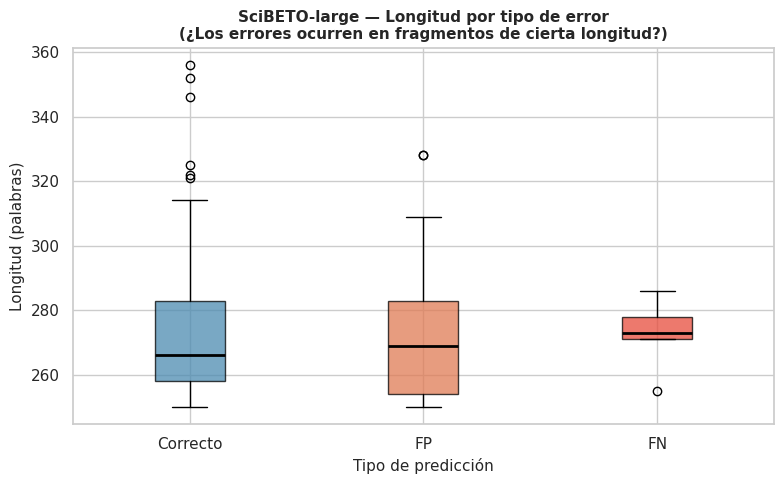

In [22]:
# ── Boxplot: longitud por tipo de predicción ──────────────────────────────────
if "scibeto" in errores and errores["scibeto"] is not None:
    df_err = errores["scibeto"]
    orden  = [t for t in ["Correcto","FP","FN"] if t in df_err["tipo"].values]
    cmap_e = {"Correcto":"#4c8bb1","FP":"#e07b54","FN":"#e74c3c"}

    fig, ax = plt.subplots(figsize=(8, 5))
    data    = [df_err[df_err["tipo"]==t]["word_count"].dropna() for t in orden]
    bp      = ax.boxplot(data, labels=orden, patch_artist=True,
                         medianprops={"color":"black","linewidth":2})
    for patch, t in zip(bp["boxes"], orden):
        patch.set_facecolor(cmap_e.get(t,"gray"))
        patch.set_alpha(0.75)

    ax.set_ylabel("Longitud (palabras)", fontsize=11)
    ax.set_xlabel("Tipo de predicción", fontsize=11)
    ax.set_title("SciBETO-large — Longitud por tipo de error\n(¿Los errores ocurren en fragmentos de cierta longitud?)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/tmp/errores_longitud.png", dpi=150)
    plt.show()

---
## 10. Reporte final (A10)

In [23]:
print("\n" + "="*75)
print("  REPORTE FINAL — TAREA 2: Detección de Contribuciones Científicas")
print(f"  Evaluación: anotacion_referencia.csv  (n={len(df_test)})")
print("  Input de todos los modelos: texto puro (sin metadatos)")
print("="*75)
print(f"\n  {'Modelo':<30} {'F1 Macro':>10} {'F1 Pos':>9} "
      f"{'Recall':>9} {'Precisión':>10} {'Accuracy':>9}")
print("  " + "─"*73)

for m_key, row in df_summary.iterrows():
    mejor = " ← MEJOR" if m_key == df_summary["f1_macro"].idxmax() else ""
    print(f"  {m_key:<30} {row['f1_macro']:>10.4f} {row['f1_positivos']:>9.4f} "
          f"{row['recall_pos']:>9.4f} {row['precision_pos']:>10.4f} "
          f"{row['accuracy']:>9.4f}{mejor}")

print("="*75)

# Comparación encoders vs LLMs
enc_keys = [k for k in df_summary.index if "SciBETO" in k or "BETO" in k]
llm_keys = [k for k in df_summary.index if "Llama" in k or "GPT" in k]

if enc_keys and llm_keys:
    best_enc = df_summary.loc[enc_keys, "f1_macro"].max()
    best_llm = df_summary.loc[llm_keys, "f1_macro"].max()
    delta    = best_enc - best_llm
    print(f"\n  Mejor encoder fine-tuned : F1 Macro = {best_enc:.4f}")
    print(f"  Mejor LLM (inferencia)   : F1 Macro = {best_llm:.4f}")
    if delta > 0:
        print(f"  → Fine-tuning supera a LLMs en Δ={delta:+.4f}")
        print(f"    El modelo aprendió semántica más allá de marcadores superficiales.")
    else:
        print(f"  → LLMs superan al encoder en Δ={abs(delta):+.4f}")
        print(f"    Posible leakage residual en el dataset o dataset insuficiente.")

# Guardar resumen
resumen_final = {
    "evaluacion"   : "anotacion_referencia.csv",
    "n_test"       : int(len(df_test)),
    "input_modelos": "texto_puro_sin_metadatos",
    "mejor_modelo" : df_summary["f1_macro"].idxmax(),
    "mejor_f1"     : round(df_summary["f1_macro"].max(), 4),
    "todos_resultados": df_summary.round(4).to_dict(),
    "wandb_project": WB_PROJECT,
    "wandb_group"  : WB_GROUP,
}
with open("/tmp/task2_resumen_final.json", "w", encoding="utf-8") as f:
    json.dump(resumen_final, f, indent=2, ensure_ascii=False)
print(f"\n  Resumen guardado en /tmp/task2_resumen_final.json")
print("="*75)


  REPORTE FINAL — TAREA 2: Detección de Contribuciones Científicas
  Evaluación: anotacion_referencia.csv  (n=200)
  Input de todos los modelos: texto puro (sin metadatos)

  Modelo                           F1 Macro    F1 Pos    Recall  Precisión  Accuracy
  ─────────────────────────────────────────────────────────────────────────
  SciBETO-large-3                    0.8485    0.8636    0.9500     0.7917    0.8500 ← MEJOR
  Llama-3.1-8B-zero-shot             0.4857    0.2903    0.1800     0.7500    0.5600
  Llama-3.1-8B-few-shot              0.4658    0.2414    0.1400     0.8750    0.5600
  GPT-4o-zero-shot                   0.4136    0.1468    0.0800     0.8889    0.5350
  GPT-4o-few-shot                    0.3967    0.1132    0.0600     1.0000    0.5300

  Mejor encoder fine-tuned : F1 Macro = 0.8485
  Mejor LLM (inferencia)   : F1 Macro = 0.4857
  → Fine-tuning supera a LLMs en Δ=+0.3627
    El modelo aprendió semántica más allá de marcadores superficiales.

  Resumen guardado en 